<a href="https://colab.research.google.com/github/VivekKatuwal/Vek/blob/main/quantumalgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1)Implement the Deutsch-Jozsa algorithm for a 2-bit oracle using Qiskit. Test it on both constant and balanced functions.
Modify your code to take a general n-bit input and automatically identify whether the oracle is constant or balanced.**

In [ ]:

%pip install qiskit qiskit-aer qiskit-ibm-runtime ipywidgets

Constant Oracle Result: {'00': 1024}
Balanced Oracle Result: {'01': 1024}


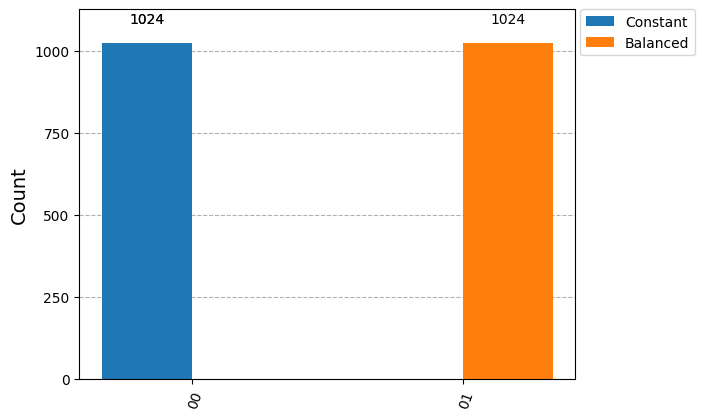

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Define constant and balanced oracles
def constant_oracle():
    oracle = QuantumCircuit(3)
    return oracle.to_gate(label="Constant")

def balanced_oracle():
    oracle = QuantumCircuit(3)
    oracle.cx(0, 2)
    return oracle.to_gate(label="Balanced")

# Deutsch-Jozsa algorithm implementation
def deutsch_jozsa(oracle):
    qc = QuantumCircuit(3, 2)

    # Initialize qubits
    qc.x(2)  # Last qubit to |1>
    qc.h([0, 1, 2])  # Apply Hadamard gates

    # Apply the oracle
    qc.append(oracle, range(3))

    # Apply Hadamard gates again to first two qubits
    qc.h([0, 1])

    # Measure the first two qubits
    qc.measure([0, 1], [0, 1])

    return qc

# Test the algorithm with constant and balanced oracles
simulator = AerSimulator()

# Constant Oracle Test
const_circuit = deutsch_jozsa(constant_oracle())
const_circuit = transpile(const_circuit, simulator)
const_result = simulator.run(const_circuit).result().get_counts()
print("Constant Oracle Result:", const_result)

# Balanced Oracle Test
bal_circuit = deutsch_jozsa(balanced_oracle())
bal_circuit = transpile(bal_circuit, simulator)
bal_result = simulator.run(bal_circuit).result().get_counts()
print("Balanced Oracle Result:", bal_result)

# Plot results
plot_histogram([const_result, bal_result], legend=["Constant", "Balanced"])


**Modified**

Constant Oracle Result for n=4: {'0000': 1024}
Balanced Oracle Result for n=4: {'1111': 1024}


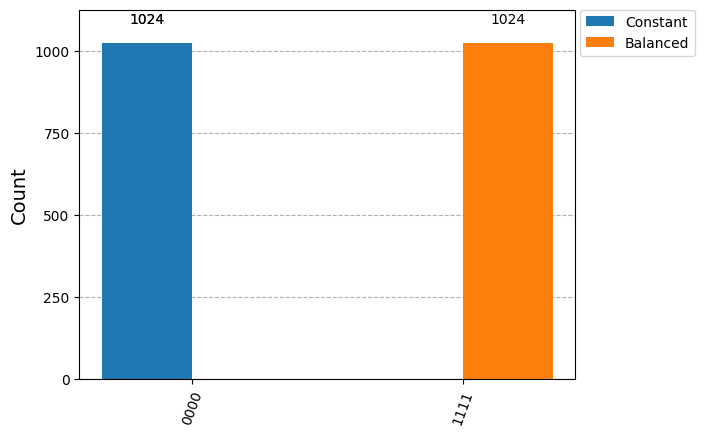

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Define constant oracle for n bits
def constant_oracle(n):
    oracle = QuantumCircuit(n + 1)  # n input bits + 1 output bit
    return oracle.to_gate(label="Constant")

# Define balanced oracle for n bits
def balanced_oracle(n):
    oracle = QuantumCircuit(n + 1)
    for i in range(n):
        oracle.cx(i, n)  # Apply CNOT from each input qubit to the output qubit
    return oracle.to_gate(label="Balanced")

# General Deutsch-Jozsa algorithm implementation
def deutsch_jozsa_general(n, oracle):
    qc = QuantumCircuit(n + 1, n)  # Create circuit with n+1 qubits and n classical bits

    # Initialize last qubit to |1>
    qc.x(n)

    # Apply Hadamard gates to all qubits
    qc.h(range(n + 1))

    # Apply the oracle
    qc.append(oracle, range(n + 1))

    # Apply Hadamard gates again to the first n qubits
    qc.h(range(n))

    # Measure the first n qubits
    qc.measure(range(n), range(n))

    return qc

# Example usage with a general n (e.g., n = 3)
n = 4

# Test with constant oracle for n=3
const_circuit_n = deutsch_jozsa_general(n, constant_oracle(n))
simulator = AerSimulator()
const_circuit_n = transpile(const_circuit_n, simulator)
const_result_n = simulator.run(const_circuit_n).result().get_counts()
print("Constant Oracle Result for n=4:", const_result_n)

# Test with balanced oracle for n=3
bal_circuit_n = deutsch_jozsa_general(n, balanced_oracle(n))
bal_circuit_n = transpile(bal_circuit_n, simulator)
bal_result_n = simulator.run(bal_circuit_n).result().get_counts()
print("Balanced Oracle Result for n=4:", bal_result_n)

# Plot results
plot_histogram([const_result_n, bal_result_n], legend=["Constant", "Balanced"])


**2)Implement Grover’s algorithm to find a marked item from a list of 4 elements.**

Grover's Algorithm Result: {'01': 282, '11': 251, '00': 240, '10': 251}


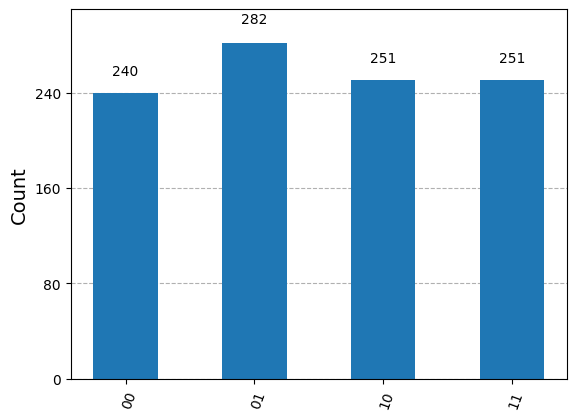

In [ ]:

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def grovers_algorithm(marked_item):
    # Create a quantum circuit with 2 qubits (for 4 elements) and 2 classical bits
    qc = QuantumCircuit(2, 2)

    # Apply Hadamard gates to all qubits to create superposition
    qc.h([0, 1])

    # Oracle: flips the sign of the marked item (e.g., |11>)
    if marked_item == '11':
        qc.cz(0, 1)  # Apply a controlled-Z gate for |11| case

    # Apply Hadamard gates again before measurement
    qc.h([0, 1])

    # Measure the qubits
    qc.measure([0, 1], [0, 1])

    return qc

# Example usage: Marked item is '11'
marked_item = '11'
grover_circuit = grovers_algorithm(marked_item)

# Set up the simulator backend
backend = AerSimulator()

# Transpile and execute Grover's algorithm circuit
grover_circuit = transpile(grover_circuit, backend)
grover_result = backend.run(grover_circuit, shots=1024).result().get_counts()
print("Grover's Algorithm Result:", grover_result)

# Plot results
plot_histogram(grover_result)


**3)Visualize the evolution of the state vector amplitude using Qiskit’s Statevector or Bloch sphere tools.**

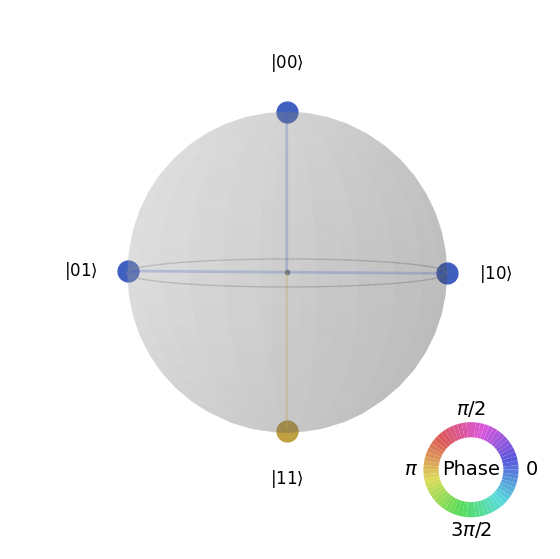

In [ ]:
from qiskit.quantum_info import Statevector

# Get statevector of Grover's circuit before measurement
statevector = Statevector.from_instruction(grover_circuit.remove_final_measurements(inplace=False))

# Visualize using Q-sphere representation
statevector.draw('qsphere')


**4)Use Qiskit’s built-in Shor’s algorithm to factor the number 15**

In [ ]:


# Modular exponentiation circuit for Shor's algorithm
def modular_exponentiation(base, exponent, modulus):
    result = 1
    base %= modulus

    while exponent > 0:
        if (exponent % 2) == 1:
            result = (result * base) % modulus

        exponent >>= 1
        base = (base * base) % modulus

    return result

# Example usage: Factorize N=15 using modular arithmetic
N = 15
a = 7  # Random base co-prime with N

# Simulate modular exponentiation
mod_exp_result = modular_exponentiation(a, 2, N)
print(f"Modular Exponentiation: {a}^2 mod {N} =", mod_exp_result)

# Construct quantum circuit for period finding (simplified example)
qc = QuantumCircuit(4)  # Adjust qubit count based on the problem size

# Apply Hadamard gates to create superposition
qc.h([0, 1, 2])

# Oracle and QFT (simplified for illustration)
qc.cz(0, 3)  # Example controlled-Z gate for oracle simulation

# Apply inverse QFT (simplified)
qc.h([0, 1, 2])

# Visualize the circuit
print(qc.draw())


Modular Exponentiation: 7^2 mod 15 = 4
     ┌───┐   ┌───┐
q_0: ┤ H ├─■─┤ H ├
     ├───┤ │ ├───┤
q_1: ┤ H ├─┼─┤ H ├
     ├───┤ │ ├───┤
q_2: ┤ H ├─┼─┤ H ├
     └───┘ │ └───┘
q_3: ──────■──────
                  


**5)Implement a simple version of modular exponentiation as used in Shor’s algorithm.**

In [ ]:
def modular_exponentiation(base, exponent, modulus):
    result = 1
    base %= modulus

    while exponent > 0:
        if (exponent % 2) == 1:
            result = (result * base) % modulus

        exponent >>= 1
        base = (base * base) % modulus

    return result

# Example usage: Calculate (2^3) mod 5
base = 2
exponent = 3
modulus = 5

mod_exp_result = modular_exponentiation(base, exponent, modulus)
print(f"{base}^{exponent} mod {modulus} =", mod_exp_result)


2^3 mod 5 = 3


**5. Discuss the current challenges in realizing these algorithms on real quantum hardware.**

**Challenges in Realizing Algorithms on Quantum Hardware:**  

1.  **Noise and Decoherence:** Qubits lose their quantum state due to environmental interactions, causing errors.  
2.  **Qubit Quality and Connectivity:** Limited qubit count, noisy qubits, and restricted connectivity require extra operations, increasing errors.  
3.  **Error Correction and Mitigation:** Large qubit overhead for error correction; mitigation techniques are still evolving.  
4.  **Algorithm Depth and Gate Fidelity:** Long circuits and limited coherence time lead to error accumulation.  
5.  **Measurement Bottlenecks:** Probabilistic measurements need repeated runs, slowing computation.  
6.  **Limited Access and Calibration:** Restricted access to hardware and frequent calibration slow down development.  
7.  **Algorithm Optimization:** Algorithms need hardware-specific optimization due to different quantum architectures.  
8.  **Scalability:** Difficulty scaling beyond hundreds of qubits while maintaining performance.  

